In [1]:
import pandas as pd

df = pd.read_csv("students.csv")

# first 5 rows
print(df.head())

# shape and data types
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)

# summary stats
print("\nSummary:\n", df.describe())

# pass/fail count
print("\nPass/Fail count:\n", df['passed'].value_counts())

# average per subject for pass vs fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("\nAvg scores - Passing students:\n", df[df['passed'] == 1][subject_cols].mean())
print("\nAvg scores - Failing students:\n", df[df['passed'] == 0][subject_cols].mean())

# top student
df['temp_avg'] = df[subject_cols].mean(axis=1)
top = df.loc[df['temp_avg'].idxmax(), 'name']
print(f"\nTop student: {top}")
df.drop(columns='temp_avg', inplace=True)


      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data types:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history         pe  att

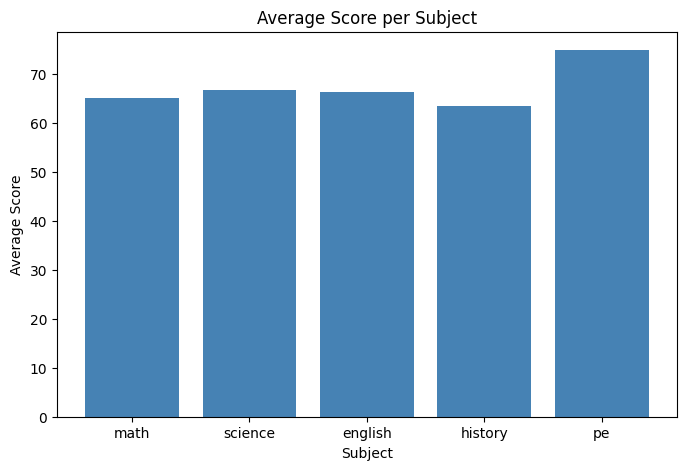

In [2]:
import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# bar chart - average score per subject
avgs = df[subject_cols].mean()
plt.figure(figsize=(8, 5))
plt.bar(avgs.index, avgs.values, color='steelblue')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


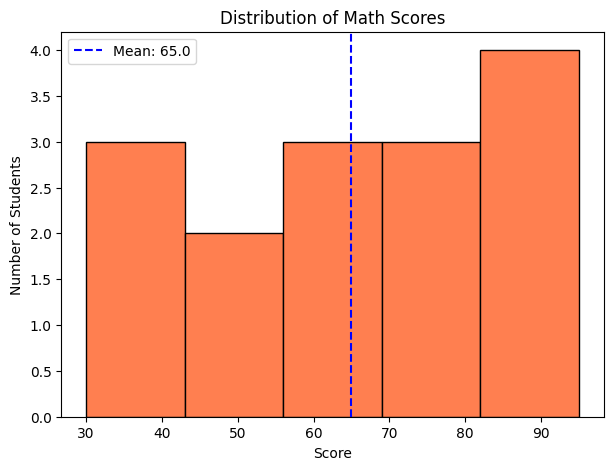

In [3]:
# histogram of math scores
plt.figure(figsize=(7, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')
mean_math = df['math'].mean()
plt.axvline(mean_math, color='blue', linestyle='--', label=f'Mean: {mean_math:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()


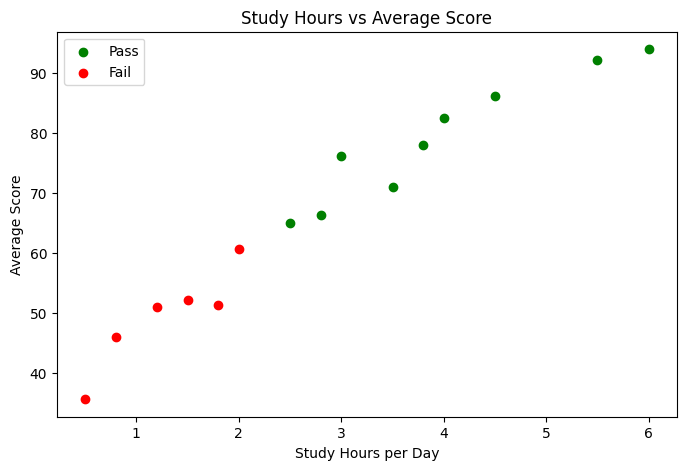

In [4]:
# scatter: study hours vs avg score, colored by pass/fail
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


C:\Users\tanma\AppData\Local\Temp\ipykernel_22800\4043772472.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


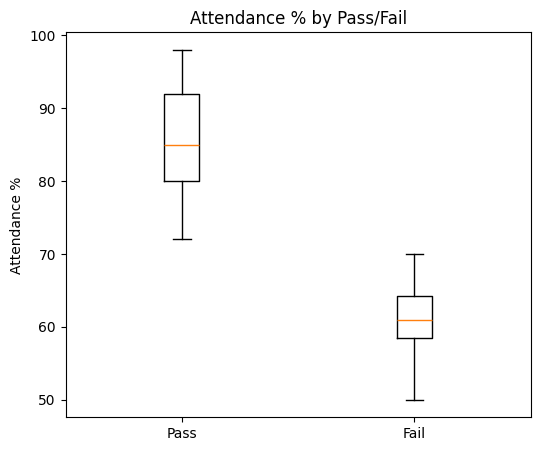

In [5]:
# box plot: attendance for pass vs fail
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(6, 5))
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title("Attendance % by Pass/Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_boxplot.png")
plt.show()


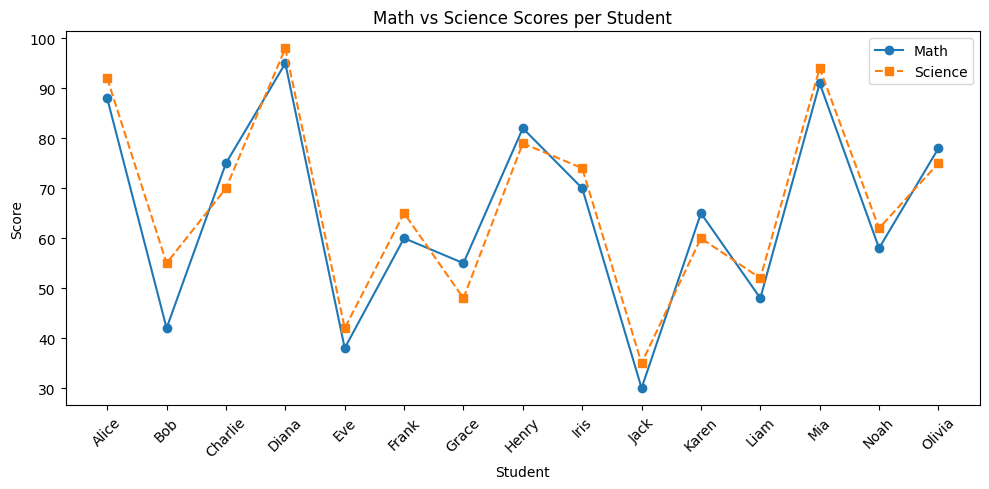

In [6]:
# line plot: math and science scores per student
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title("Math vs Science Scores per Student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


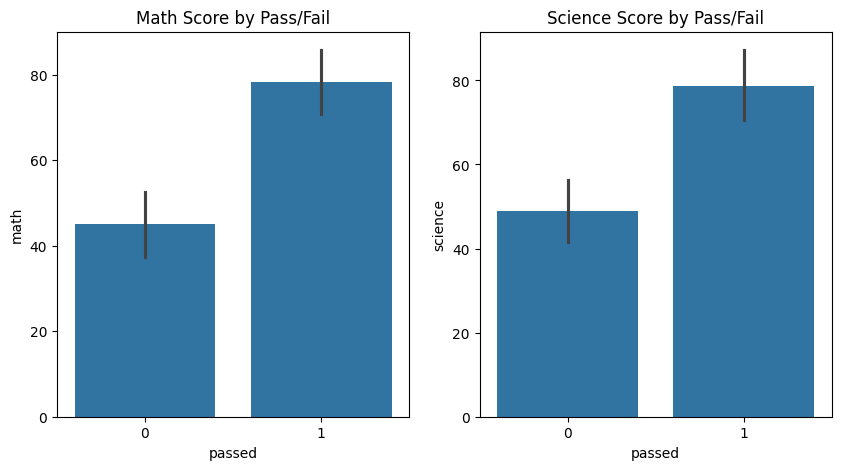

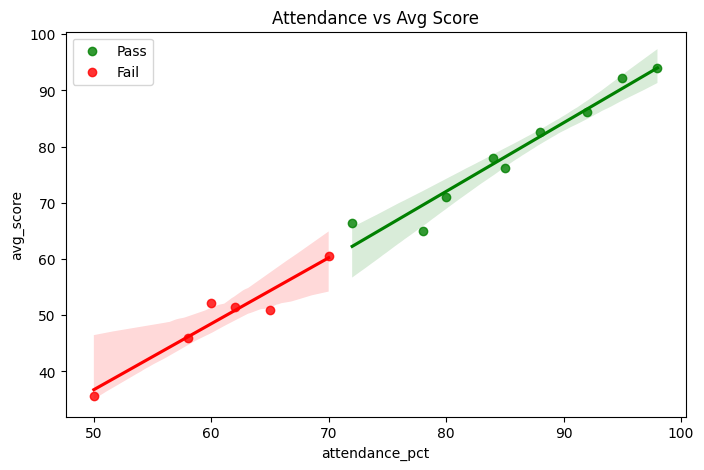

In [7]:
import seaborn as sns

# seaborn bar: math and science by pass/fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax1.set_title("Math Score by Pass/Fail")
ax2.set_title("Science Score by Pass/Fail")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# seaborn scatter + regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', scatter_kws={'color':'green'}, line_kws={'color':'green'})
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', scatter_kws={'color':'red'}, line_kws={'color':'red'})
plt.title("Attendance vs Avg Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn handles grouping automatically which is simpler than matplotlib.
# Matplotlib needs more manual setup but gives more control over styling.
# For quick grouped plots, seaborn is much faster to write.

Training accuracy: 1.00
Test accuracy: 1.00
Jack: Actual=0, Predicted=0 
Liam: Actual=0, Predicted=0 
Alice: Actual=1, Predicted=1 

Feature Importance:
  english                  : 0.8125
  attendance_pct           : 0.5219
  study_hours_per_day      : 0.4844
  pe                       : 0.4750
  math                     : 0.4379
  science                  : 0.3230
  history                  : 0.2629


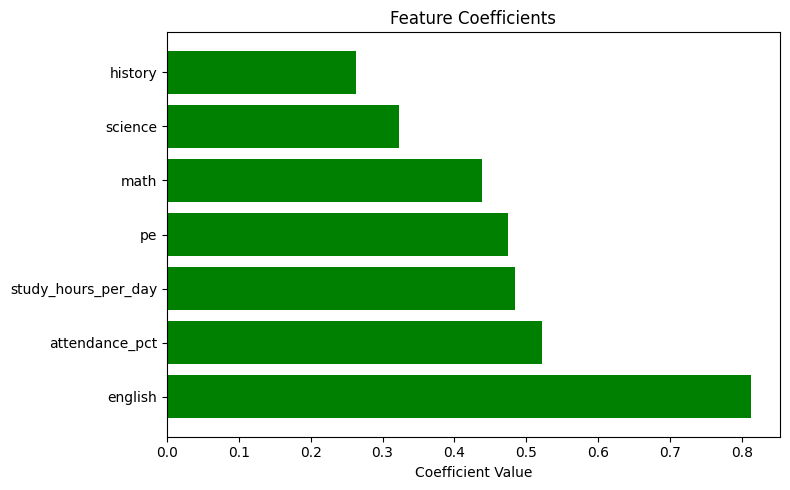

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print(f"Training accuracy: {model.score(X_train_scaled, y_train):.2f}")

# evaluate
y_pred = model.predict(X_test_scaled)
print(f"Test accuracy: {model.score(X_test_scaled, y_test):.2f}")

# per-student result
names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(names, y_test, y_pred):
    mark = "" if actual == pred else ""
    print(f"{name}: Actual={actual}, Predicted={pred} {mark}")

# feature importance
coeffs = model.coef_[0]
feat_imp = sorted(zip(feature_cols, coeffs), key=lambda x: abs(x[1]), reverse=True)
print("\nFeature Importance:")
for feat, coef in feat_imp:
    print(f"  {feat:<25}: {coef:.4f}")

# bar chart of coefficients
colors = ['green' if c > 0 else 'red' for _, c in feat_imp]
plt.figure(figsize=(8, 5))
plt.barh([f for f, _ in feat_imp], [c for _, c in feat_imp], color=colors)
plt.title("Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("plot8_features.png")
plt.show()
